# Cross-Asset Backtesting Lab

This notebook focuses on the regime-scan 

In [197]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


In [198]:
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

prices = pd.read_csv('prices.csv', parse_dates=['Date']).set_index('Date')
all_assets = list(prices.columns)
idx_assets = [c for c in all_assets if c.startswith('Idx_')]
non_idx_assets = [c for c in all_assets if not c.startswith('Idx_')]

split_idx = int(len(prices) * 0.60)
train_prices = prices.iloc[:split_idx].copy()
test_prices = prices.iloc[split_idx:].copy()
split_date = prices.index[split_idx]

pd.Series({
    'Total rows': len(prices),
    'Training rows': len(train_prices),
    'Test rows': len(test_prices),
    'Train start': train_prices.index.min(),
    'Train end': train_prices.index.max(),
    'Test start': test_prices.index.min(),
    'Test end': test_prices.index.max(),
    'Non-Idx assets': len(non_idx_assets),
})

Total rows                       2271
Training rows                    1362
Test rows                         909
Train start       1990-01-02 00:00:00
Train end         1995-03-22 00:00:00
Test start        1995-03-23 00:00:00
Test end          1998-09-15 00:00:00
Non-Idx assets                     27
dtype: object

## Index Versus Non-Index Asset Statistics

For each `Idx_*` and every non-`Idx_*` asset pair, compute conditional next-day returns when the index is in a high-z stress regime or a low-z calm regime.

In [199]:
REGIME_WINDOW = 40
HIGH_STRESS_Z = 1.5
LOW_STRESS_Z = -0.5


def build_idx_non_idx_stats(prices, idx_assets, non_idx_assets, regime_window=40, high_z=1.5, low_z=-0.5):
    returns = prices.pct_change()
    rows = []

    for idx in idx_assets:
        idx_mean = prices[idx].rolling(regime_window).mean()
        idx_std = prices[idx].rolling(regime_window).std()
        idx_z = (prices[idx] - idx_mean) / idx_std.replace(0, np.nan)

        stress_mask = idx_z.shift(1) > high_z
        calm_mask = idx_z.shift(1) < low_z

        for asset in non_idx_assets:
            stress_next = returns.loc[stress_mask, asset]
            calm_next = returns.loc[calm_mask, asset]
            stress_bps = float(stress_next.mean() * 10000) if len(stress_next.dropna()) else np.nan
            calm_bps = float(calm_next.mean() * 10000) if len(calm_next.dropna()) else np.nan
            rows.append({
                'RegimeAsset': idx,
                'TargetAsset': asset,
                'StressCount': int(stress_mask.sum()),
                'CalmCount': int(calm_mask.sum()),
                'StressNextBps': stress_bps,
                'CalmNextBps': calm_bps,
                'StressEdge': stress_bps - calm_bps,
                'CalmEdge': calm_bps - stress_bps,
                'Correlation': float(returns[idx].corr(returns[asset])),
            })

    pair_stats = pd.DataFrame(rows)
    pair_stats.to_csv(OUTPUT_DIR / 'idx_non_idx_regime_stats.csv', index=False)
    return pair_stats


pair_stats = build_idx_non_idx_stats(
    train_prices,
    idx_assets,
    non_idx_assets,
    regime_window=REGIME_WINDOW,
    high_z=HIGH_STRESS_Z,
    low_z=LOW_STRESS_Z,
)

pair_stats.to_csv(OUTPUT_DIR / 'idx_non_idx_regime_stats_train.csv', index=False)
pair_stats.sort_values(['RegimeAsset', 'StressEdge'], ascending=[True, False]).head(20)

,RegimeAsset,TargetAsset,StressCount,CalmCount,StressNextBps,CalmNextBps,StressEdge,CalmEdge,Correlation
21,Idx_01,FX_01,163,589,18.959249,-6.099517,25.058766,-25.058766,0.089450
3,Idx_01,Stock_04,163,589,12.759993,-4.470720,17.230713,-17.230713,-0.326315
25,Idx_01,FX_05,163,589,10.821948,-4.965766,15.787714,-15.787714,0.075450
16,Idx_01,Comm_02,163,589,8.642673,-2.942098,11.584772,-11.584772,-0.038649
7,Idx_01,Stock_08,163,589,2.517911,-8.931781,11.449692,-11.449692,-0.558834
5,Idx_01,Stock_06,163,589,-1.158636,-5.716133,4.557497,-4.557497,-0.641394
12,Idx_01,Stock_13,163,589,0.517825,-1.230687,1.748512,-1.748512,-0.342567
15,Idx_01,Comm_01,163,589,-5.880523,-2.669480,-3.211043,3.211043,-0.170818
24,Idx_01,FX_04,163,589,-7.305642,1.556360,-8.862002,8.862002,-0.052449
17,Idx_01,Comm_03,163,589,-19.232311,-8.712753,-10.519558,10.519558,-0.317414


In [200]:
def summarize_triplets(pair_stats):
    rows = []
    for idx in sorted(pair_stats['RegimeAsset'].unique()):
        sub = pair_stats[pair_stats['RegimeAsset'] == idx].copy()
        defensive = sub.sort_values(['StressEdge', 'StressNextBps'], ascending=False).iloc[0]
        cyclical_pool = sub[sub['TargetAsset'] != defensive['TargetAsset']]
        cyclical = cyclical_pool.sort_values(['CalmEdge', 'CalmNextBps'], ascending=False).iloc[0]
        rows.append({
            'RegimeAsset': idx,
            'DefensiveAsset': defensive['TargetAsset'],
            'StressNextBps_Def': defensive['StressNextBps'],
            'CalmNextBps_Def': defensive['CalmNextBps'],
            'CyclicalAsset': cyclical['TargetAsset'],
            'StressNextBps_Cyc': cyclical['StressNextBps'],
            'CalmNextBps_Cyc': cyclical['CalmNextBps'],
        })
    return pd.DataFrame(rows)


triplet_summary = summarize_triplets(pair_stats)
triplet_summary

,RegimeAsset,DefensiveAsset,StressNextBps_Def,CalmNextBps_Def,CyclicalAsset,StressNextBps_Cyc,CalmNextBps_Cyc
0,Idx_01,FX_01,18.959249,-6.099517,Stock_09,-82.220171,35.991387
1,Idx_02,Stock_09,69.126924,-18.342526,Comm_04,-14.509570,8.080698
2,Idx_03,Stock_09,56.416596,-33.940283,FX_01,-15.388209,12.332835
3,Idx_04,Stock_12,13.972027,-10.190104,Stock_15,-31.298058,-10.011050


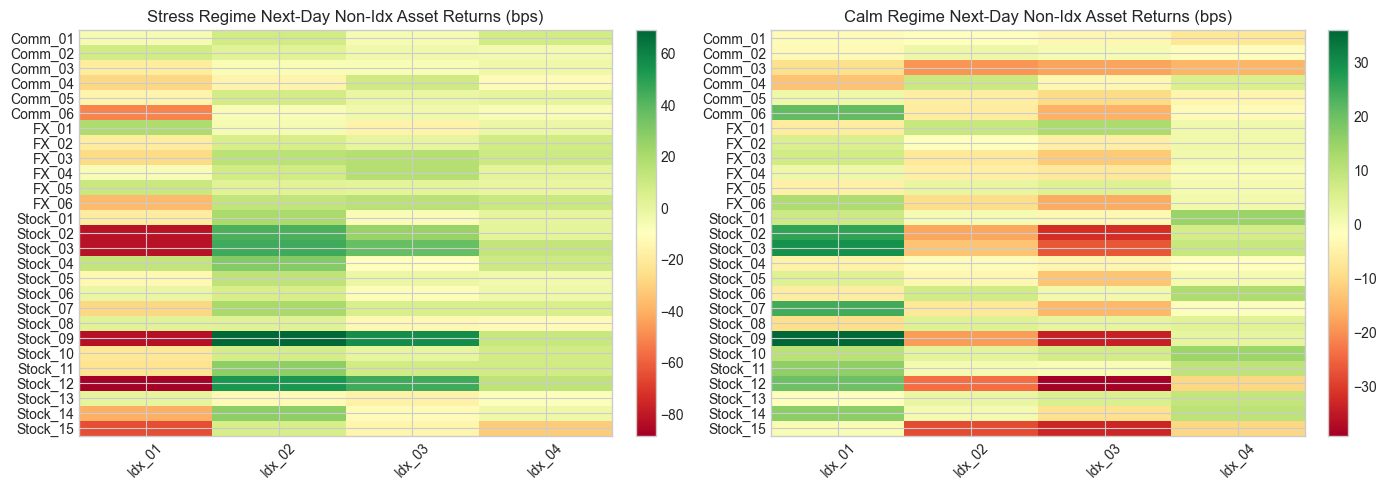

In [201]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stress_pivot = pair_stats.pivot(index='TargetAsset', columns='RegimeAsset', values='StressNextBps')
calm_pivot = pair_stats.pivot(index='TargetAsset', columns='RegimeAsset', values='CalmNextBps')

im0 = axes[0].imshow(stress_pivot.values, aspect='auto', cmap='RdYlGn')
axes[0].set_title('Stress Regime Next-Day Non-Idx Asset Returns (bps)')
axes[0].set_xticks(range(len(stress_pivot.columns)), stress_pivot.columns, rotation=45)
axes[0].set_yticks(range(len(stress_pivot.index)), stress_pivot.index)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(calm_pivot.values, aspect='auto', cmap='RdYlGn')
axes[1].set_title('Calm Regime Next-Day Non-Idx Asset Returns (bps)')
axes[1].set_xticks(range(len(calm_pivot.columns)), calm_pivot.columns, rotation=45)
axes[1].set_yticks(range(len(calm_pivot.index)), calm_pivot.index)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Helpers

In [202]:
def compute_regime_triplet_backtest(
    prices,
    regime_asset,
    defensive_asset,
    cyclical_asset,
    regime_window=40,
    vol_window=20,
    high_stress_z=1.5,
    low_stress_z=-0.5,
    target_vol=0.012,
    max_gross_exposure=0.95,
    index_weight=0.40,
    defensive_weight=1.00,
    cyclical_weight=1.00,
    initial_cash=100_000,
    signal_to_return_lag=2,
):
    asset_cols = [regime_asset, defensive_asset, cyclical_asset]
    asset_prices = prices[asset_cols].astype(float).copy()
    if len(asset_prices) <= signal_to_return_lag:
        return None

    asset_returns = asset_prices.pct_change().fillna(0.0)
    regime_mean = asset_prices[regime_asset].rolling(regime_window).mean()
    regime_std = asset_prices[regime_asset].rolling(regime_window).std()
    regime_z = (asset_prices[regime_asset] - regime_mean) / regime_std.replace(0, np.nan)

    base_weights = pd.Series(
        {
            regime_asset: -index_weight,
            defensive_asset: defensive_weight,
            cyclical_asset: -cyclical_weight,
        },
        dtype=float,
    )
    base_weights = base_weights / base_weights.abs().sum()

    basket_proxy_returns = (asset_returns * base_weights).sum(axis=1)
    basket_vol = basket_proxy_returns.rolling(
        vol_window,
        min_periods=max(5, vol_window // 2),
    ).std()

    signal = pd.Series(0.0, index=asset_prices.index)
    signal = signal.mask(regime_z > high_stress_z, 1.0)
    signal = signal.mask(regime_z < low_stress_z, -1.0)

    gross_target = (target_vol / basket_vol).clip(upper=max_gross_exposure)
    gross_target = gross_target.where(
        np.isfinite(gross_target) & (basket_vol > 0),
        0.0,
    ).fillna(0.0)

    target_weights = pd.DataFrame(0.0, index=asset_prices.index, columns=asset_cols)
    for asset, base_weight in base_weights.items():
        target_weights[asset] = signal * gross_target * base_weight

    # The hackathon simulator fills a day-T signal at the day-(T+1) close.
    # With close-to-close returns, the first realized PnL from that fill appears
    # on the day-(T+2) return row, so the signal-to-return lag is 2 bars.
    executed_weights = target_weights.shift(signal_to_return_lag).fillna(0.0)
    portfolio_returns = (executed_weights * asset_returns).sum(axis=1).fillna(0.0)
    equity_curve = initial_cash * (1.0 + portfolio_returns).cumprod()
    drawdown = equity_curve / equity_curve.cummax() - 1.0

    weight_changes = target_weights.diff().fillna(target_weights)
    trade_count = int((weight_changes.abs() > 1e-12).sum().sum())
    exposure_time = float((executed_weights.abs().sum(axis=1) > 0).mean() * 100.0)

    returns_std = float(portfolio_returns.std())
    sharpe = 0.0 if returns_std == 0 else float(np.sqrt(260) * portfolio_returns.mean() / returns_std)
    total_return = float((equity_curve.iloc[-1] / initial_cash - 1.0) * 100.0)
    max_drawdown = float(drawdown.min() * 100.0)
    equity_final = float(equity_curve.iloc[-1])

    portfolio_df = pd.DataFrame(
        {
            'Portfolio Return': portfolio_returns,
            'Equity': equity_curve,
            'Drawdown': drawdown,
            'RegimeZ': regime_z,
            'Signal': signal,
            'Gross Target': gross_target,
            'Gross Exposure': executed_weights.abs().sum(axis=1),
        },
        index=asset_prices.index,
    )
    for asset in asset_cols:
        portfolio_df[f'{asset}_Weight'] = executed_weights[asset]
        portfolio_df[f'{asset}_Price'] = asset_prices[asset]
        portfolio_df[f'{asset}_Return'] = asset_returns[asset]

    summary = {
        'Return [%]': total_return,
        'Sharpe Ratio': sharpe,
        'Max. Drawdown [%]': max_drawdown,
        '# Trades': trade_count,
        'Exposure Time [%]': exposure_time,
        'Equity Final [$]': equity_final,
    }

    return {
        'summary': summary,
        'portfolio': portfolio_df,
        'asset_prices': asset_prices,
        'asset_returns': asset_returns,
        'target_weights': target_weights,
        'executed_weights': executed_weights,
    }


## Portfolio Construction

Backtest each triplet as a real three-asset portfolio with separate weights on the regime asset, defensive asset, and cyclical asset.

Signals are generated from day-`T` closes and the hackathon simulator fills them at day-`T+1` closes. Because the notebook uses close-to-close returns, the first realized portfolio return from a day-`T` signal shows up on the day-`T+2` row.

In [203]:
TARGET_VOL = 0.012
MAX_GROSS_EXPOSURE = 0.95
INDEX_WEIGHT = 0.40
DEFENSIVE_WEIGHT = 1.00
CYCLICAL_WEIGHT = 1.00
INITIAL_CASH = 100_000
SIMULATOR_EXECUTION_LAG = 1
SIGNAL_TO_RETURN_LAG = 2

pd.Series({
    'Target vol': TARGET_VOL,
    'Max gross exposure': MAX_GROSS_EXPOSURE,
    'Index weight': INDEX_WEIGHT,
    'Defensive weight': DEFENSIVE_WEIGHT,
    'Cyclical weight': CYCLICAL_WEIGHT,
    'Initial cash': INITIAL_CASH,
    'Simulator execution lag (days)': SIMULATOR_EXECUTION_LAG,
    'Signal-to-return lag (bars)': SIGNAL_TO_RETURN_LAG,
})


Target vol                             0.012
Max gross exposure                     0.950
Index weight                           0.400
Defensive weight                       1.000
Cyclical weight                        1.000
Initial cash                      100000.000
Simulator execution lag (days)         1.000
Signal-to-return lag (bars)            2.000
dtype: float64

## Cross-Asset Regime Portfolio Search

Search `Idx_* + non-Idx + non-Idx` triplets on the 60% training split for each index in **`REGIME_ASSET_CANDIDATES`** (default: every `Idx_*` in `prices.csv`). Rank by train backtest performance, filter on train-side thresholds, then evaluate selected triplets on the 40% test split. The **by-regime** summary is computed after `triplet_ranking`.


In [205]:
# Which `Idx_*` columns to use as the regime leg in the grid below.
REGIME_ASSET_CANDIDATES = list(idx_assets)
# e.g. restrict: REGIME_ASSET_CANDIDATES = ["Idx_01", "Idx_02"]

candidate_triplets = []
for regime_asset in REGIME_ASSET_CANDIDATES:
    non_idx_choices = sorted(non_idx_assets)
    for defensive_asset in non_idx_choices:
        for cyclical_asset in non_idx_choices:
            if defensive_asset == cyclical_asset:
                continue
            candidate_triplets.append({
                'RegimeAsset': regime_asset,
                'DefensiveAsset': defensive_asset,
                'CyclicalAsset': cyclical_asset,
            })

candidate_triplets = pd.DataFrame(candidate_triplets)
candidate_triplets.head()

,RegimeAsset,DefensiveAsset,CyclicalAsset
0,Idx_01,Comm_01,Comm_02
1,Idx_01,Comm_01,Comm_03
2,Idx_01,Comm_01,Comm_04
3,Idx_01,Comm_01,Comm_05
4,Idx_01,Comm_01,Comm_06


In [206]:
triplet_rows = []
triplet_backtests_train = {}

for row in candidate_triplets.itertuples(index=False):
    train_result = compute_regime_triplet_backtest(
        train_prices,
        regime_asset=row.RegimeAsset,
        defensive_asset=row.DefensiveAsset,
        cyclical_asset=row.CyclicalAsset,
        regime_window=REGIME_WINDOW,
        vol_window=20,
        high_stress_z=HIGH_STRESS_Z,
        low_stress_z=LOW_STRESS_Z,
        target_vol=TARGET_VOL,
        max_gross_exposure=MAX_GROSS_EXPOSURE,
        index_weight=INDEX_WEIGHT,
        defensive_weight=DEFENSIVE_WEIGHT,
        cyclical_weight=CYCLICAL_WEIGHT,
        initial_cash=INITIAL_CASH,
        signal_to_return_lag=SIGNAL_TO_RETURN_LAG,
    )
    if train_result is None or len(train_result['portfolio']) < 100:
        continue

    key = (row.RegimeAsset, row.DefensiveAsset, row.CyclicalAsset)
    triplet_backtests_train[key] = train_result
    summary = train_result['summary']
    triplet_rows.append({
        'RegimeAsset': row.RegimeAsset,
        'DefensiveAsset': row.DefensiveAsset,
        'CyclicalAsset': row.CyclicalAsset,
        'Train Return [%]': summary['Return [%]'],
        'Train Sharpe Ratio': summary['Sharpe Ratio'],
        'Train Max. Drawdown [%]': summary['Max. Drawdown [%]'],
        'Train # Trades': summary['# Trades'],
        'Train Exposure Time [%]': summary['Exposure Time [%]'],
        'Train Equity Final [$]': summary['Equity Final [$]'],
    })

triplet_ranking = pd.DataFrame(triplet_rows).sort_values(
    ['Train Sharpe Ratio', 'Train Return [%]'], ascending=[False, False]
)
triplet_ranking.to_csv(OUTPUT_DIR / 'backtesting_cross_asset_triplet_ranking_train.csv', index=False)
triplet_ranking.head(80)

# By regime index: which Idx_* had the strongest train triplets?
regime_train_compare = (
    triplet_ranking.groupby('RegimeAsset', as_index=False)
    .agg(
        n_triplets=('Train Sharpe Ratio', 'size'),
        best_sharpe=('Train Sharpe Ratio', 'max'),
        best_return=('Train Return [%]', 'max'),
        median_sharpe=('Train Sharpe Ratio', 'median'),
    )
    .sort_values('best_sharpe', ascending=False)
)
regime_train_compare


,RegimeAsset,DefensiveAsset,CyclicalAsset,Train Return [%],Train Sharpe Ratio,Train Max. Drawdown [%],Train # Trades,Train Exposure Time [%],Train Equity Final [$]
281,Idx_01,FX_05,Stock_11,291.641958,2.068941,-8.188295,1413,55.139501,391641.957699
255,Idx_01,FX_04,Stock_11,295.759877,2.067570,-9.356588,1482,55.139501,395759.877457
229,Idx_01,FX_03,Stock_11,298.203528,2.054939,-9.647106,1512,55.139501,398203.527727
265,Idx_01,FX_05,Comm_06,373.570881,1.952503,-12.618562,2082,55.139501,473570.880854
239,Idx_01,FX_04,Comm_06,375.600312,1.944946,-13.649326,2118,55.139501,475600.312432
...,...,...,...,...,...,...,...,...,...
447,Idx_01,Stock_06,Comm_06,271.344628,1.576926,-14.196462,2484,55.139501,371344.627529
158,Idx_01,FX_01,Comm_03,210.104697,1.576266,-12.918729,1530,55.139501,310104.696632
306,Idx_01,FX_06,Stock_10,192.469669,1.574971,-12.214273,1479,55.139501,292469.668846
672,Idx_01,Stock_14,Stock_11,239.783228,1.573370,-14.145741,2079,55.139501,339783.227736


In [207]:
MIN_TRAIN_SHARPE = 1.0
MIN_TRAIN_RETURN = 180.0
MAX_TRAIN_DRAWDOWN = -16.0
MAX_SELECTED_TRIPLETS = 50

candidate_triplets_filtered = triplet_ranking[
    (triplet_ranking['Train Sharpe Ratio'] >= MIN_TRAIN_SHARPE)
    & (triplet_ranking['Train Return [%]'] >= MIN_TRAIN_RETURN)
    & (triplet_ranking['Train Max. Drawdown [%]'] >= MAX_TRAIN_DRAWDOWN)
].copy().reset_index(drop=True)

selection_source = (
    candidate_triplets_filtered
    if not candidate_triplets_filtered.empty
    else triplet_ranking.copy().reset_index(drop=True)
)

# Greedy selection: keep the regime asset reusable, but do not reuse
# defensive or cyclical assets across the final selected triplets.
selected_rows = []
used_traded_assets = set()
for _, row in selection_source.iterrows():
    defensive_asset = row['DefensiveAsset']
    cyclical_asset = row['CyclicalAsset']
    if defensive_asset in used_traded_assets or cyclical_asset in used_traded_assets:
        continue
    selected_rows.append(row.to_dict())
    used_traded_assets.update({defensive_asset, cyclical_asset})
    if len(selected_rows) >= MAX_SELECTED_TRIPLETS:
        break

selected_triplets = pd.DataFrame(selected_rows)
if selected_triplets.empty:
    raise ValueError('No triplets selected under the non-overlapping traded-asset rule.')

selected_triplets.insert(0, 'Selected Rank', np.arange(1, len(selected_triplets) + 1))
selected_triplets.to_csv(OUTPUT_DIR / 'backtesting_cross_asset_selected_triplets_train.csv', index=False)

cross_asset_backtests = {}
test_equity_curve_map = {}
test_return_curve_map = {}
cross_asset_rows = []

for _, row in selected_triplets.iterrows():
    selection_rank = int(row['Selected Rank'])
    regime_asset = row['RegimeAsset']
    defensive_asset = row['DefensiveAsset']
    cyclical_asset = row['CyclicalAsset']
    key = (regime_asset, defensive_asset, cyclical_asset)

    cross_asset_backtests[key] = {}
    for split_name, dataset in [('train', train_prices), ('test', test_prices)]:
        result = compute_regime_triplet_backtest(
            dataset,
            regime_asset=regime_asset,
            defensive_asset=defensive_asset,
            cyclical_asset=cyclical_asset,
            regime_window=REGIME_WINDOW,
            vol_window=20,
            high_stress_z=HIGH_STRESS_Z,
            low_stress_z=LOW_STRESS_Z,
            target_vol=TARGET_VOL,
            max_gross_exposure=MAX_GROSS_EXPOSURE,
            index_weight=INDEX_WEIGHT,
            defensive_weight=DEFENSIVE_WEIGHT,
            cyclical_weight=CYCLICAL_WEIGHT,
            initial_cash=INITIAL_CASH,
            signal_to_return_lag=SIGNAL_TO_RETURN_LAG,
        )
        if result is None:
            continue

        cross_asset_backtests[key][split_name] = result
        summary = result['summary']
        if split_name == 'test':
            test_equity_curve_map[key] = result['portfolio']['Equity'].copy()
            test_return_curve_map[key] = (result['portfolio']['Equity'] / INITIAL_CASH - 1.0) * 100.0

        cross_asset_rows.append({
            'Selected Rank': selection_rank,
            'Split': split_name,
            'RegimeAsset': regime_asset,
            'DefensiveAsset': defensive_asset,
            'CyclicalAsset': cyclical_asset,
            'Return [%]': summary['Return [%]'],
            'Sharpe Ratio': summary['Sharpe Ratio'],
            'Max. Drawdown [%]': summary['Max. Drawdown [%]'],
            '# Trades': summary['# Trades'],
            'Exposure Time [%]': summary['Exposure Time [%]'],
            'Equity Final [$]': summary['Equity Final [$]'],
        })

cross_asset_summary = pd.DataFrame(cross_asset_rows)
cross_asset_summary.to_csv(OUTPUT_DIR / 'backtesting_cross_asset_regime_train_test_summary.csv', index=False)

cross_asset_test_summary = (
    cross_asset_summary[cross_asset_summary['Split'] == 'test']
    .sort_values('Selected Rank')
    .reset_index(drop=True)
)
cross_asset_test_summary.to_csv(OUTPUT_DIR / 'backtesting_cross_asset_regime_test_summary.csv', index=False)

cross_asset_test_summary


,Selected Rank,Split,RegimeAsset,DefensiveAsset,CyclicalAsset,Return [%],Sharpe Ratio,Max. Drawdown [%],# Trades,Exposure Time [%],Equity Final [$]
0,1,test,Idx_01,FX_05,Stock_11,101.888882,1.353323,-17.775128,954,54.125413,201888.882039
1,2,test,Idx_01,FX_04,Comm_06,71.373971,0.996485,-18.920355,1425,54.125413,171373.970785
2,3,test,Idx_01,FX_03,Stock_02,112.086000,1.389470,-17.376607,1047,54.125413,212085.999644
3,4,test,Idx_01,FX_06,Stock_07,92.857283,1.239575,-18.248150,1029,54.125413,192857.283014
4,5,test,Idx_01,Stock_08,Comm_03,149.517740,1.635243,-17.639373,1290,54.125413,249517.739917
5,6,test,Idx_01,FX_02,Stock_09,125.193536,1.490816,-15.040879,1176,54.125413,225193.536212
6,7,test,Idx_01,Stock_13,Stock_10,47.193573,0.692506,-23.592954,1353,54.125413,147193.572769
7,8,test,Idx_01,Stock_05,Stock_06,60.873047,0.897402,-17.708796,1392,54.125413,160873.046733
8,9,test,Idx_01,Comm_02,Comm_05,95.047210,1.331686,-16.795218,1023,54.125413,195047.210443
9,10,test,Idx_01,FX_01,Stock_03,85.504988,1.151367,-17.846383,1086,54.125413,185504.988107


### Robustness: Idx_01 vs Idx_02 vs Idx_03 on the **test** window

Same train ranking, `MIN_TRAIN_*` filters, and greedy non-overlap as above — but run **separately** with only one regime leg at a time. Then we summarize **test-only** Sharpe/return across the selected triplets. Compare `mean_test_sharpe` across legs.


In [ ]:
# Robustness: same train rules + greedy selection, then **test** metrics — Idx_01 vs Idx_02 vs Idx_03
REGIME_ROBUSTNESS_LEGS = ["Idx_01", "Idx_02", "Idx_03"]

def _rank_train_and_greedy_single_regime(regime_asset: str) -> pd.DataFrame:
    """Train triplet ranking + MIN_TRAIN_* filters + greedy non-overlap (same as main pipeline)."""
    rows_c = []
    for defn in sorted(non_idx_assets):
        for cyc in sorted(non_idx_assets):
            if defn == cyc:
                continue
            rows_c.append(
                {"RegimeAsset": regime_asset, "DefensiveAsset": defn, "CyclicalAsset": cyc}
            )
    cand = pd.DataFrame(rows_c)
    triplet_rows = []
    for row in cand.itertuples(index=False):
        train_result = compute_regime_triplet_backtest(
            train_prices,
            regime_asset=row.RegimeAsset,
            defensive_asset=row.DefensiveAsset,
            cyclical_asset=row.CyclicalAsset,
            regime_window=REGIME_WINDOW,
            vol_window=20,
            high_stress_z=HIGH_STRESS_Z,
            low_stress_z=LOW_STRESS_Z,
            target_vol=TARGET_VOL,
            max_gross_exposure=MAX_GROSS_EXPOSURE,
            index_weight=INDEX_WEIGHT,
            defensive_weight=DEFENSIVE_WEIGHT,
            cyclical_weight=CYCLICAL_WEIGHT,
            initial_cash=INITIAL_CASH,
            signal_to_return_lag=SIGNAL_TO_RETURN_LAG,
        )
        if train_result is None or len(train_result["portfolio"]) < 100:
            continue
        summary = train_result["summary"]
        triplet_rows.append(
            {
                "RegimeAsset": row.RegimeAsset,
                "DefensiveAsset": row.DefensiveAsset,
                "CyclicalAsset": row.CyclicalAsset,
                "Train Return [%]": summary["Return [%]"],
                "Train Sharpe Ratio": summary["Sharpe Ratio"],
                "Train Max. Drawdown [%]": summary["Max. Drawdown [%]"],
                "Train # Trades": summary["# Trades"],
                "Train Exposure Time [%]": summary["Exposure Time [%]"],
                "Train Equity Final [$]": summary["Equity Final [$]"],
            }
        )
    triplet_ranking_r = pd.DataFrame(triplet_rows).sort_values(
        ["Train Sharpe Ratio", "Train Return [%]"], ascending=[False, False]
    )
    filt = triplet_ranking_r[
        (triplet_ranking_r["Train Sharpe Ratio"] >= MIN_TRAIN_SHARPE)
        & (triplet_ranking_r["Train Return [%]"] >= MIN_TRAIN_RETURN)
        & (triplet_ranking_r["Train Max. Drawdown [%]"] >= MAX_TRAIN_DRAWDOWN)
    ].copy().reset_index(drop=True)
    selection_source = (
        filt if not filt.empty else triplet_ranking_r.copy().reset_index(drop=True)
    )
    selected_rows = []
    used_traded_assets = set()
    for _, row in selection_source.iterrows():
        da, ca = row["DefensiveAsset"], row["CyclicalAsset"]
        if da in used_traded_assets or ca in used_traded_assets:
            continue
        selected_rows.append(row.to_dict())
        used_traded_assets.update({da, ca})
        if len(selected_rows) >= MAX_SELECTED_TRIPLETS:
            break
    out = pd.DataFrame(selected_rows)
    if out.empty:
        return out
    out.insert(0, "Selected Rank", np.arange(1, len(out) + 1))
    return out


robustness_test_rows = []
for leg in REGIME_ROBUSTNESS_LEGS:
    sel = _rank_train_and_greedy_single_regime(leg)
    if sel.empty:
        robustness_test_rows.append(
            {
                "RegimeAsset": leg,
                "n_selected": 0,
                "mean_test_sharpe": np.nan,
                "median_test_sharpe": np.nan,
                "best_test_sharpe": np.nan,
                "mean_test_return_pct": np.nan,
            }
        )
        continue
    test_metrics = []
    for _, row in sel.iterrows():
        res = compute_regime_triplet_backtest(
            test_prices,
            regime_asset=row["RegimeAsset"],
            defensive_asset=row["DefensiveAsset"],
            cyclical_asset=row["CyclicalAsset"],
            regime_window=REGIME_WINDOW,
            vol_window=20,
            high_stress_z=HIGH_STRESS_Z,
            low_stress_z=LOW_STRESS_Z,
            target_vol=TARGET_VOL,
            max_gross_exposure=MAX_GROSS_EXPOSURE,
            index_weight=INDEX_WEIGHT,
            defensive_weight=DEFENSIVE_WEIGHT,
            cyclical_weight=CYCLICAL_WEIGHT,
            initial_cash=INITIAL_CASH,
            signal_to_return_lag=SIGNAL_TO_RETURN_LAG,
        )
        if res is None:
            continue
        s = res["summary"]
        test_metrics.append(
            {
                "Test Sharpe Ratio": s["Sharpe Ratio"],
                "Test Return [%]": s["Return [%]"],
            }
        )
    tm = pd.DataFrame(test_metrics)
    robustness_test_rows.append(
        {
            "RegimeAsset": leg,
            "n_selected": len(sel),
            "mean_test_sharpe": tm["Test Sharpe Ratio"].mean(),
            "median_test_sharpe": tm["Test Sharpe Ratio"].median(),
            "best_test_sharpe": tm["Test Sharpe Ratio"].max(),
            "mean_test_return_pct": tm["Test Return [%]"].mean(),
        }
    )

regime_robustness_test = (
    pd.DataFrame(robustness_test_rows).sort_values("mean_test_sharpe", ascending=False)
)
regime_robustness_test.to_csv(
    OUTPUT_DIR / "backtesting_cross_asset_regime_robustness_test_by_leg.csv", index=False
)
regime_robustness_test


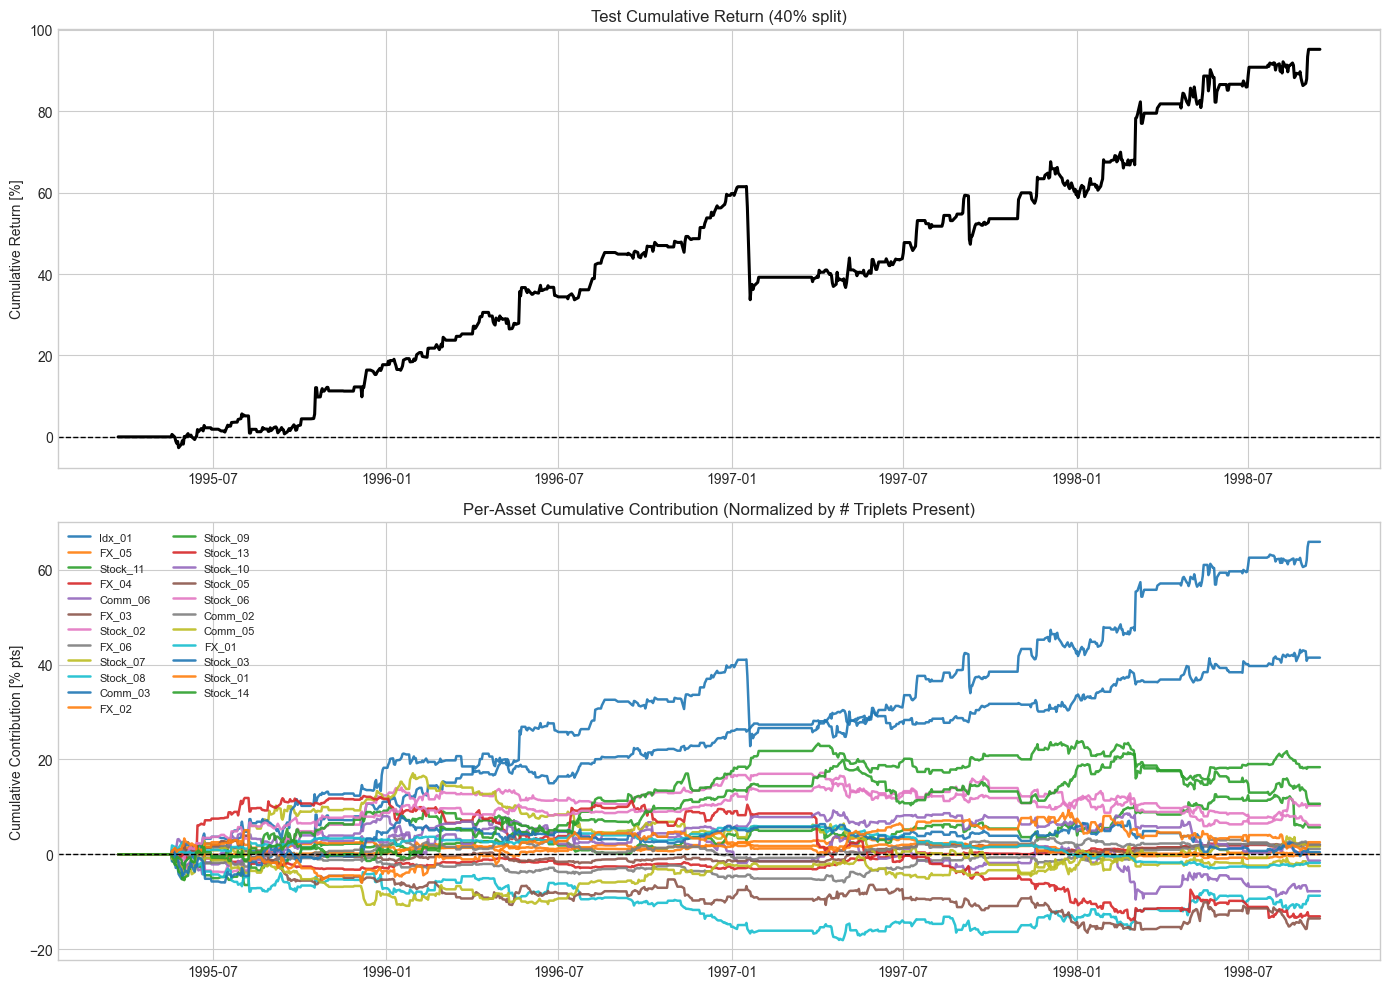

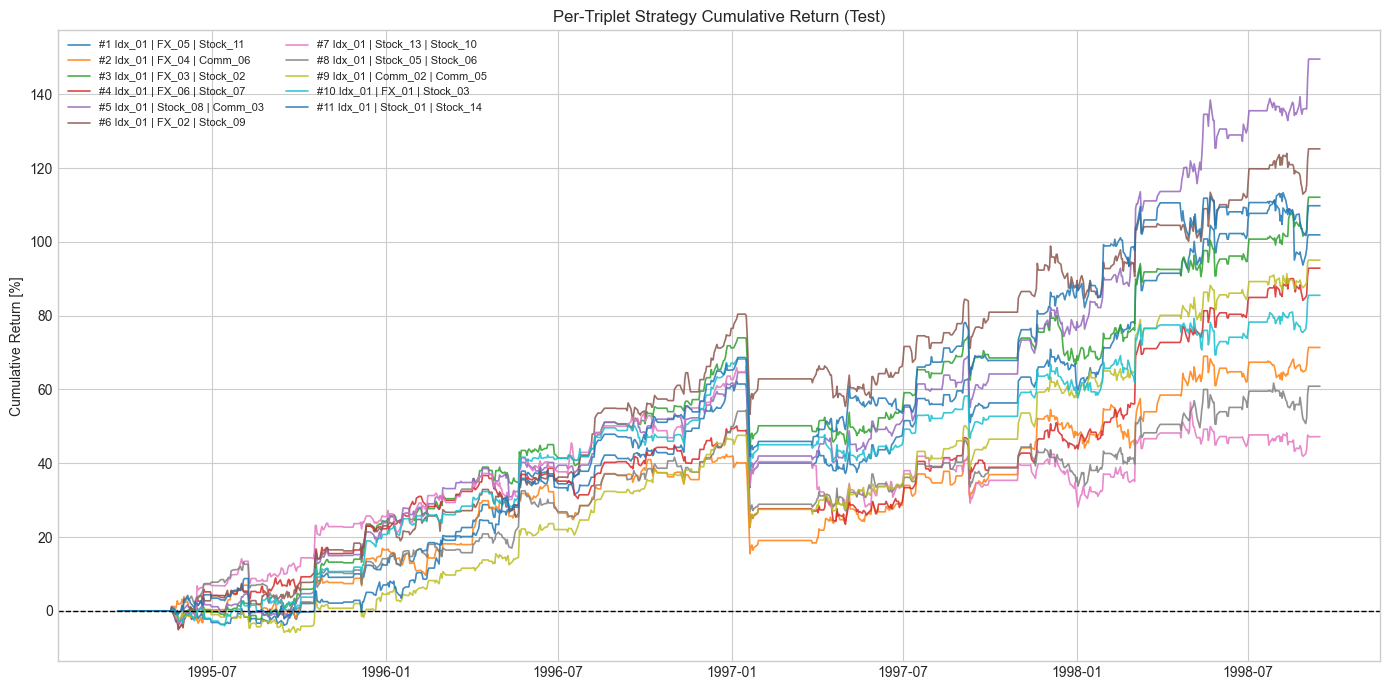

,Selected Triplets,Unique Assets,Test Return [%],Test Sharpe Ratio,Test Max. Drawdown [%],Total Underlying Triplet Trades
0,11,23,95.214866,1.347656,-17.233818,13149


,Asset,Test Strategy Contribution [% pts],Selected Triplet Count,Selected Triplet
0,Idx_01,65.892363,11,#1 Idx_01 | FX_05 | Stock_11 ; #10 Idx_01 | FX...
1,Comm_03,41.470108,1,#5 Idx_01 | Stock_08 | Comm_03
2,Stock_09,18.371384,1,#6 Idx_01 | FX_02 | Stock_09
3,Stock_14,10.656691,1,#11 Idx_01 | Stock_01 | Stock_14
4,Stock_02,10.298478,1,#3 Idx_01 | FX_03 | Stock_02
5,Stock_06,6.164313,1,#8 Idx_01 | Stock_05 | Stock_06
6,Stock_11,5.694475,1,#1 Idx_01 | FX_05 | Stock_11
7,Stock_01,2.548483,1,#11 Idx_01 | Stock_01 | Stock_14
8,FX_03,2.063049,1,#3 Idx_01 | FX_03 | Stock_02
9,Comm_02,2.034738,1,#9 Idx_01 | Comm_02 | Comm_05


In [209]:
from IPython.display import display

selected_asset_columns = ['RegimeAsset', 'DefensiveAsset', 'CyclicalAsset']
selected_assets = sorted(pd.unique(pd.concat(
    [cross_asset_test_summary[column] for column in selected_asset_columns],
    ignore_index=True,
)))
if not selected_assets:
    raise ValueError('No selected assets available to analyse.')

asset_triplet_rows = []
triplet_test_returns = []
asset_contribution_frames = []
for _, row in cross_asset_test_summary.iterrows():
    triplet_label = (
        f"#{int(row['Selected Rank'])} "
        f"{row['RegimeAsset']} | {row['DefensiveAsset']} | {row['CyclicalAsset']}"
    )
    key = (row['RegimeAsset'], row['DefensiveAsset'], row['CyclicalAsset'])
    portfolio = cross_asset_backtests[key]['test']['portfolio'].copy()
    triplet_test_returns.append(portfolio['Portfolio Return'].rename(triplet_label))

    contribution_frame = pd.DataFrame(index=portfolio.index)
    for asset in (row['RegimeAsset'], row['DefensiveAsset'], row['CyclicalAsset']):
        asset_triplet_rows.append({
            'Asset': asset,
            'Selected Triplet': triplet_label,
        })
        contribution_frame[asset] = portfolio[f'{asset}_Weight'] * portfolio[f'{asset}_Return']
    asset_contribution_frames.append(contribution_frame)

asset_triplet_map = (
    pd.DataFrame(asset_triplet_rows)
    .groupby('Asset')['Selected Triplet']
    .agg(lambda values: ' ; '.join(sorted(pd.unique(values))))
    .reset_index()
)
asset_triplet_counts = (
    pd.DataFrame(asset_triplet_rows)
    .groupby('Asset')['Selected Triplet']
    .nunique()
    .rename('Selected Triplet Count')
    .reset_index()
)

n_selected_triplets = len(cross_asset_test_summary)
triplet_test_returns = pd.concat(triplet_test_returns, axis=1).sort_index().fillna(0.0)
combined_strategy_daily_returns = triplet_test_returns.mean(axis=1)
combined_strategy_equity = INITIAL_CASH * (1.0 + combined_strategy_daily_returns).cumprod()
combined_strategy_cumulative_returns = (combined_strategy_equity / INITIAL_CASH - 1.0) * 100.0
combined_strategy_drawdown = combined_strategy_equity / combined_strategy_equity.cummax() - 1.0

asset_daily_contributions = (
    pd.concat(asset_contribution_frames)
    .groupby(level=0)
    .sum()
    .sort_index()
    .reindex(triplet_test_returns.index, fill_value=0.0)
)

# Normalize contributions so an asset isn't diluted just because it only appears
# in a subset of the selected triplets.
asset_triplet_count_map = (
    asset_triplet_counts.set_index('Asset')['Selected Triplet Count']
    .reindex(asset_daily_contributions.columns)
)
asset_daily_contributions = asset_daily_contributions.div(asset_triplet_count_map, axis=1)
asset_cumulative_contributions = asset_daily_contributions.cumsum() * 100.0

combined_strategy_summary = pd.DataFrame([{
    'Selected Triplets': n_selected_triplets,
    'Unique Assets': len(selected_assets),
    'Test Return [%]': combined_strategy_cumulative_returns.iloc[-1],
    'Test Sharpe Ratio': 0.0 if combined_strategy_daily_returns.std() == 0 else float(np.sqrt(260) * combined_strategy_daily_returns.mean() / combined_strategy_daily_returns.std()),
    'Test Max. Drawdown [%]': float(combined_strategy_drawdown.min() * 100.0),
    'Total Underlying Triplet Trades': int(cross_asset_test_summary['# Trades'].sum()),
}])

asset_summary = (
    asset_cumulative_contributions.iloc[-1]
    .sort_values(ascending=False)
    .rename('Test Strategy Contribution [% pts]')
    .rename_axis('Asset')
    .reset_index()
    .merge(asset_triplet_counts, on='Asset', how='left')
    .merge(asset_triplet_map, on='Asset', how='left')
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
axes[0].plot(combined_strategy_cumulative_returns.index, combined_strategy_cumulative_returns.values, color='black', linewidth=2.2)
axes[0].set_title('Test Cumulative Return (40% split)')
axes[0].set_ylabel('Cumulative Return [%]')
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)

for asset in asset_cumulative_contributions.columns:
    axes[1].plot(asset_cumulative_contributions.index, asset_cumulative_contributions[asset], label=asset, linewidth=1.8, alpha=0.9)
axes[1].set_title('Per-Asset Cumulative Contribution (Normalized by # Triplets Present)')
axes[1].set_ylabel('Cumulative Contribution [% pts]')
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1].legend(loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# Plot cumulative returns for each selected triplet strategy.
# Each column in `triplet_test_returns` is the daily portfolio return from one triplet.
triplet_equity = INITIAL_CASH * (1.0 + triplet_test_returns).cumprod()
triplet_cum_returns = (triplet_equity / INITIAL_CASH - 1.0) * 100.0

plt.figure(figsize=(14, 7))
for col in triplet_cum_returns.columns:
    plt.plot(
        triplet_cum_returns.index,
        triplet_cum_returns[col],
        linewidth=1.2,
        alpha=0.85,
        # Avoid an unreadable legend when there are many triplets.
        label=col if len(triplet_cum_returns.columns) <= 15 else None,
    )

plt.title('Per-Triplet Strategy Cumulative Return (Test)')
plt.ylabel('Cumulative Return [%]')
plt.axhline(0.0, color='black', linestyle='--', linewidth=1.0)
if len(triplet_cum_returns.columns) <= 15:
    plt.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

display(combined_strategy_summary)
asset_summary


In [210]:
label_map = {
    (
        row['RegimeAsset'],
        row['DefensiveAsset'],
        row['CyclicalAsset'],
    ): f"#{int(row['Selected Rank'])} {row['RegimeAsset']} | {row['DefensiveAsset']} | {row['CyclicalAsset']}"
    for _, row in cross_asset_test_summary.iterrows()
}

test_equity_curves = pd.DataFrame({
    label_map[key]: series for key, series in test_equity_curve_map.items()
}).sort_index()
test_equity_curves.to_csv(OUTPUT_DIR / 'backtesting_cross_asset_test_equity_curves.csv', index_label='Date')

test_cumulative_returns = pd.DataFrame({
    label_map[key]: series for key, series in test_return_curve_map.items()
}).sort_index()
test_cumulative_returns.to_csv(OUTPUT_DIR / 'backtesting_cross_asset_test_cumulative_returns.csv', index_label='Date')

asset_cumulative_returns.to_csv(
    OUTPUT_DIR / 'backtesting_cross_asset_selected_assets_test_cumulative_returns.csv',
    index_label='Date',
)
asset_summary.to_csv(
    OUTPUT_DIR / 'backtesting_cross_asset_selected_assets_test_cumulative_returns_summary.csv',
    index=False,
)

first_selected = cross_asset_test_summary.iloc[0]
first_key = (
    first_selected['RegimeAsset'],
    first_selected['DefensiveAsset'],
    first_selected['CyclicalAsset'],
)
first_test_result = cross_asset_backtests[first_key]['test']
first_test_result['portfolio'].to_csv(
    OUTPUT_DIR / 'backtesting_cross_asset_first_selected_test_portfolio.csv',
    index_label='Date',
)
first_test_result['asset_prices'].to_csv(
    OUTPUT_DIR / 'backtesting_cross_asset_first_selected_test_asset_prices.csv',
    index_label='Date',
)

pd.Series({
    'Selected triplets (train)': str(OUTPUT_DIR / 'backtesting_cross_asset_selected_triplets_train.csv'),
    'Train/test summary': str(OUTPUT_DIR / 'backtesting_cross_asset_regime_train_test_summary.csv'),
    'Test summary': str(OUTPUT_DIR / 'backtesting_cross_asset_regime_test_summary.csv'),
    'Test equity curves': str(OUTPUT_DIR / 'backtesting_cross_asset_test_equity_curves.csv'),
    'Test cumulative returns': str(OUTPUT_DIR / 'backtesting_cross_asset_test_cumulative_returns.csv'),
    'Selected assets cumulative returns': str(OUTPUT_DIR / 'backtesting_cross_asset_selected_assets_test_cumulative_returns.csv'),
    'Selected assets cumulative returns summary': str(OUTPUT_DIR / 'backtesting_cross_asset_selected_assets_test_cumulative_returns_summary.csv'),
    'First selected test portfolio': str(OUTPUT_DIR / 'backtesting_cross_asset_first_selected_test_portfolio.csv'),
    'First selected test asset prices': str(OUTPUT_DIR / 'backtesting_cross_asset_first_selected_test_asset_prices.csv'),
})


Selected triplets (train)                     outputs/backtesting_cross_asset_selected_tripl...
Train/test summary                            outputs/backtesting_cross_asset_regime_train_t...
Test summary                                  outputs/backtesting_cross_asset_regime_test_su...
Test equity curves                            outputs/backtesting_cross_asset_test_equity_cu...
Test cumulative returns                       outputs/backtesting_cross_asset_test_cumulativ...
Selected assets cumulative returns            outputs/backtesting_cross_asset_selected_asset...
Selected assets cumulative returns summary    outputs/backtesting_cross_asset_selected_asset...
First selected test portfolio                 outputs/backtesting_cross_asset_first_selected...
First selected test asset prices              outputs/backtesting_cross_asset_first_selected...
dtype: str